# KNN
### 목표
1. KNN에서 K값이 성능에 어떤 영향을 주는지 확인
2. 표준화 전/후 성능 차이 확인
3. train 정확도와 test 정확도를 비교해서 과적합/과소적합 감 잡기

---

# 1. 데이터 불러오기

In [48]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("클래스 이름:", cancer.target_names)

X_train shape: (455, 30)
X_test shape: (114, 30)
클래스 이름: ['malignant' 'benign']


---

# 2. K값 하나로 먼저 확인

일단 K=3 으로 표준화 없음 / 표준화 적용 비교

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 표준화 적용 X
model_no_scaled = KNeighborsClassifier(n_neighbors=3)

model_no_scaled.fit(X_train, y_train)

train_no_scaled = model_no_scaled.score(X_train, y_train)
test_no_scaled = model_no_scaled.score(X_test, y_test)

# 표준화 적용
model_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

model_scaled.fit(X_train, y_train)

train_scaled = model_scaled.score(X_train, y_train)
test_scaled = model_scaled.score(X_test, y_test)

print("표준화 없음")
print("Train 정확도:", train_no_scaled)
print("Test 정확도:", test_no_scaled)

print()

print("표준화 적용")
print("Train 정확도:", train_scaled)
print("Test 정확도:", test_scaled)

표준화 없음
Train 정확도: 0.9538461538461539
Test 정확도: 0.9298245614035088

표준화 적용
Train 정확도: 0.978021978021978
Test 정확도: 0.9824561403508771


위에서 표준화 적용 후 Test 정확도가 올라갔고
- ### KNN은 feature scale의 영향을 많이 받는다

라고 해석하면 된다.

---

# 3. K값 여러 개 비교하기

K = 1, 3, 5, ..., 29 까지 바꿔가면서 성능 비교

In [50]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

results = []

for k in range(1, 30, 2):
    # 표준화 안 함
    model_no_scaled = KNeighborsClassifier(n_neighbors=k)
    model_no_scaled.fit(X_train, y_train)

    train_no_scaled = model_no_scaled.score(X_train, y_train)
    test_no_scaled = model_no_scaled.score(X_test, y_test)

    # 표준화 적용
    model_scaled = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model_scaled.fit(X_train, y_train)

    train_scaled = model_scaled.score(X_train, y_train)
    test_scaled = model_scaled.score(X_test, y_test)

    results.append({
        "K": k,
        "Train_표준화없음": train_no_scaled,
        "Test_표준화없음": test_no_scaled,
        "Train_표준화적용": train_scaled,
        "Test_표준화적용": test_scaled
    })

result_df = pd.DataFrame(results)
result_df

,K,Train_표준화없음,Test_표준화없음,Train_표준화적용,Test_표준화적용
0,1,1.000000,0.921053,1.000000,0.938596
1,3,0.953846,0.929825,0.978022,0.982456
2,5,0.947253,0.912281,0.973626,0.956140
3,7,0.947253,0.929825,0.975824,0.973684
4,9,0.945055,0.938596,0.973626,0.973684
5,11,0.940659,0.938596,0.971429,0.973684
6,13,0.940659,0.947368,0.971429,0.973684
7,15,0.942857,0.929825,0.969231,0.973684
8,17,0.936264,0.938596,0.962637,0.982456
9,19,0.931868,0.938596,0.967033,0.973684


---

# 4. Test 정확도 높은 순서로 보기

표준화를 적용한 KNN 기준으로 가장 좋은 K값을 확인해보면

In [51]:
result_df.sort_values("Test_표준화적용", ascending=False)

,K,Train_표준화없음,Test_표준화없음,Train_표준화적용,Test_표준화적용
1,3,0.953846,0.929825,0.978022,0.982456
8,17,0.936264,0.938596,0.962637,0.982456
4,9,0.945055,0.938596,0.973626,0.973684
5,11,0.940659,0.938596,0.971429,0.973684
6,13,0.940659,0.947368,0.971429,0.973684
7,15,0.942857,0.929825,0.969231,0.973684
3,7,0.947253,0.929825,0.975824,0.973684
9,19,0.931868,0.938596,0.967033,0.973684
10,21,0.934066,0.938596,0.964835,0.964912
12,25,0.934066,0.938596,0.964835,0.964912


표준화 없는 경우도 확인하려면

In [52]:
result_df.sort_values("Test_표준화없음", ascending=False)

,K,Train_표준화없음,Test_표준화없음,Train_표준화적용,Test_표준화적용
6,13,0.940659,0.947368,0.971429,0.973684
4,9,0.945055,0.938596,0.973626,0.973684
5,11,0.940659,0.938596,0.971429,0.973684
11,23,0.929670,0.938596,0.960440,0.956140
10,21,0.934066,0.938596,0.964835,0.964912
9,19,0.931868,0.938596,0.967033,0.973684
8,17,0.936264,0.938596,0.962637,0.982456
13,27,0.927473,0.938596,0.962637,0.947368
12,25,0.934066,0.938596,0.964835,0.964912
14,29,0.925275,0.938596,0.960440,0.947368


---

# 5. 그래프로 보기

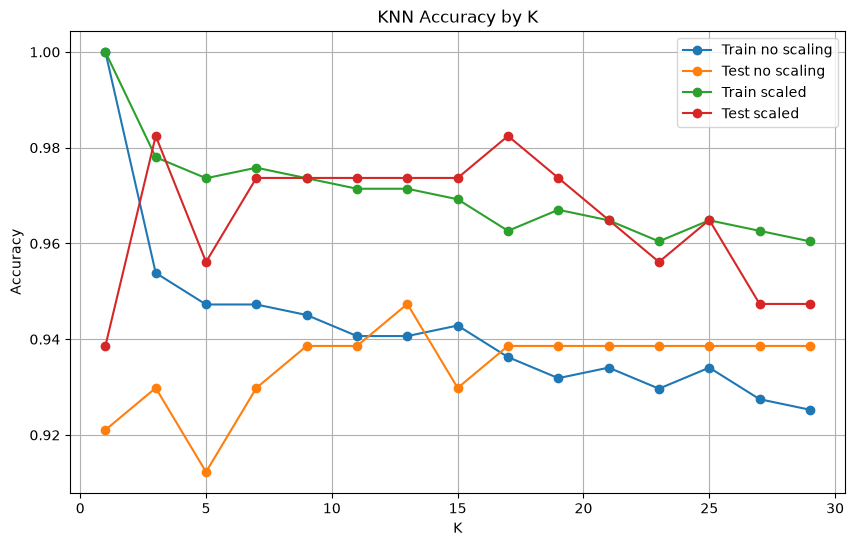

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(result_df["K"], result_df["Train_표준화없음"], marker="o", label="Train no scaling")
plt.plot(result_df["K"], result_df["Test_표준화없음"], marker="o", label="Test no scaling")
plt.plot(result_df["K"], result_df["Train_표준화적용"], marker="o", label="Train scaled")
plt.plot(result_df["K"], result_df["Test_표준화적용"], marker="o", label="Test scaled")

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy by K")
plt.legend()
plt.grid(True)
plt.show()

---

# 6. 결과 해석법

## K가 작을 때
예를 들어 K=1 이면 가장 가까운 데이터 1개만 보고 판단한다.

```text

K가 작다
-> 학습 데이터에 민감하다
-> Train 정확도가 높게 나올 가능성이 크다
-> 과적합 위험이 있다
```

특히 K=1 은 자기 주변 가장 가까운 데이터 하나만 보기 때문에 노이즈에 약하다.

---

## K가 커질 때

예를 들어 K=21, K=29 처럼 커지면 주변 데이터를 많이 보고 판단한다.

```text

K가 크다
-> 판단 기준이 부드러워진다.
-> 노이즈에는 덜 민감하다.
-> 너무 크면 세밀한 경계를 못 잡는다.
-> 과소적합 위험이 있다.
```

---

## 표준화 영향

KNN은 거리 기반 모델이다.

```text

표준화 없음
-> 값 범위가 큰 feature가 거리 계산을 지배할 수 있음
-> 거리 계산이 더 균형 있게 이루어짐
```

그래서 KNN에서는 보통 표준화를 적용하는 쪽이 더 안정적이다.